# Tool: RNA-seq Expression Heatmap (genes x samples)
# Input: /home/amohs002/projects/research/NGS/pberg/PKL/data/output/edger_filtered_results.csv
# Output: /home/amohs002/projects/research/NGS/pberg/PKL/data/output/edger_expression_heatmap.pdf
Saving heatmap to: /home/amohs002/projects/research/NGS/pberg/PKL/data/output/edger_expression_heatmap.pdf


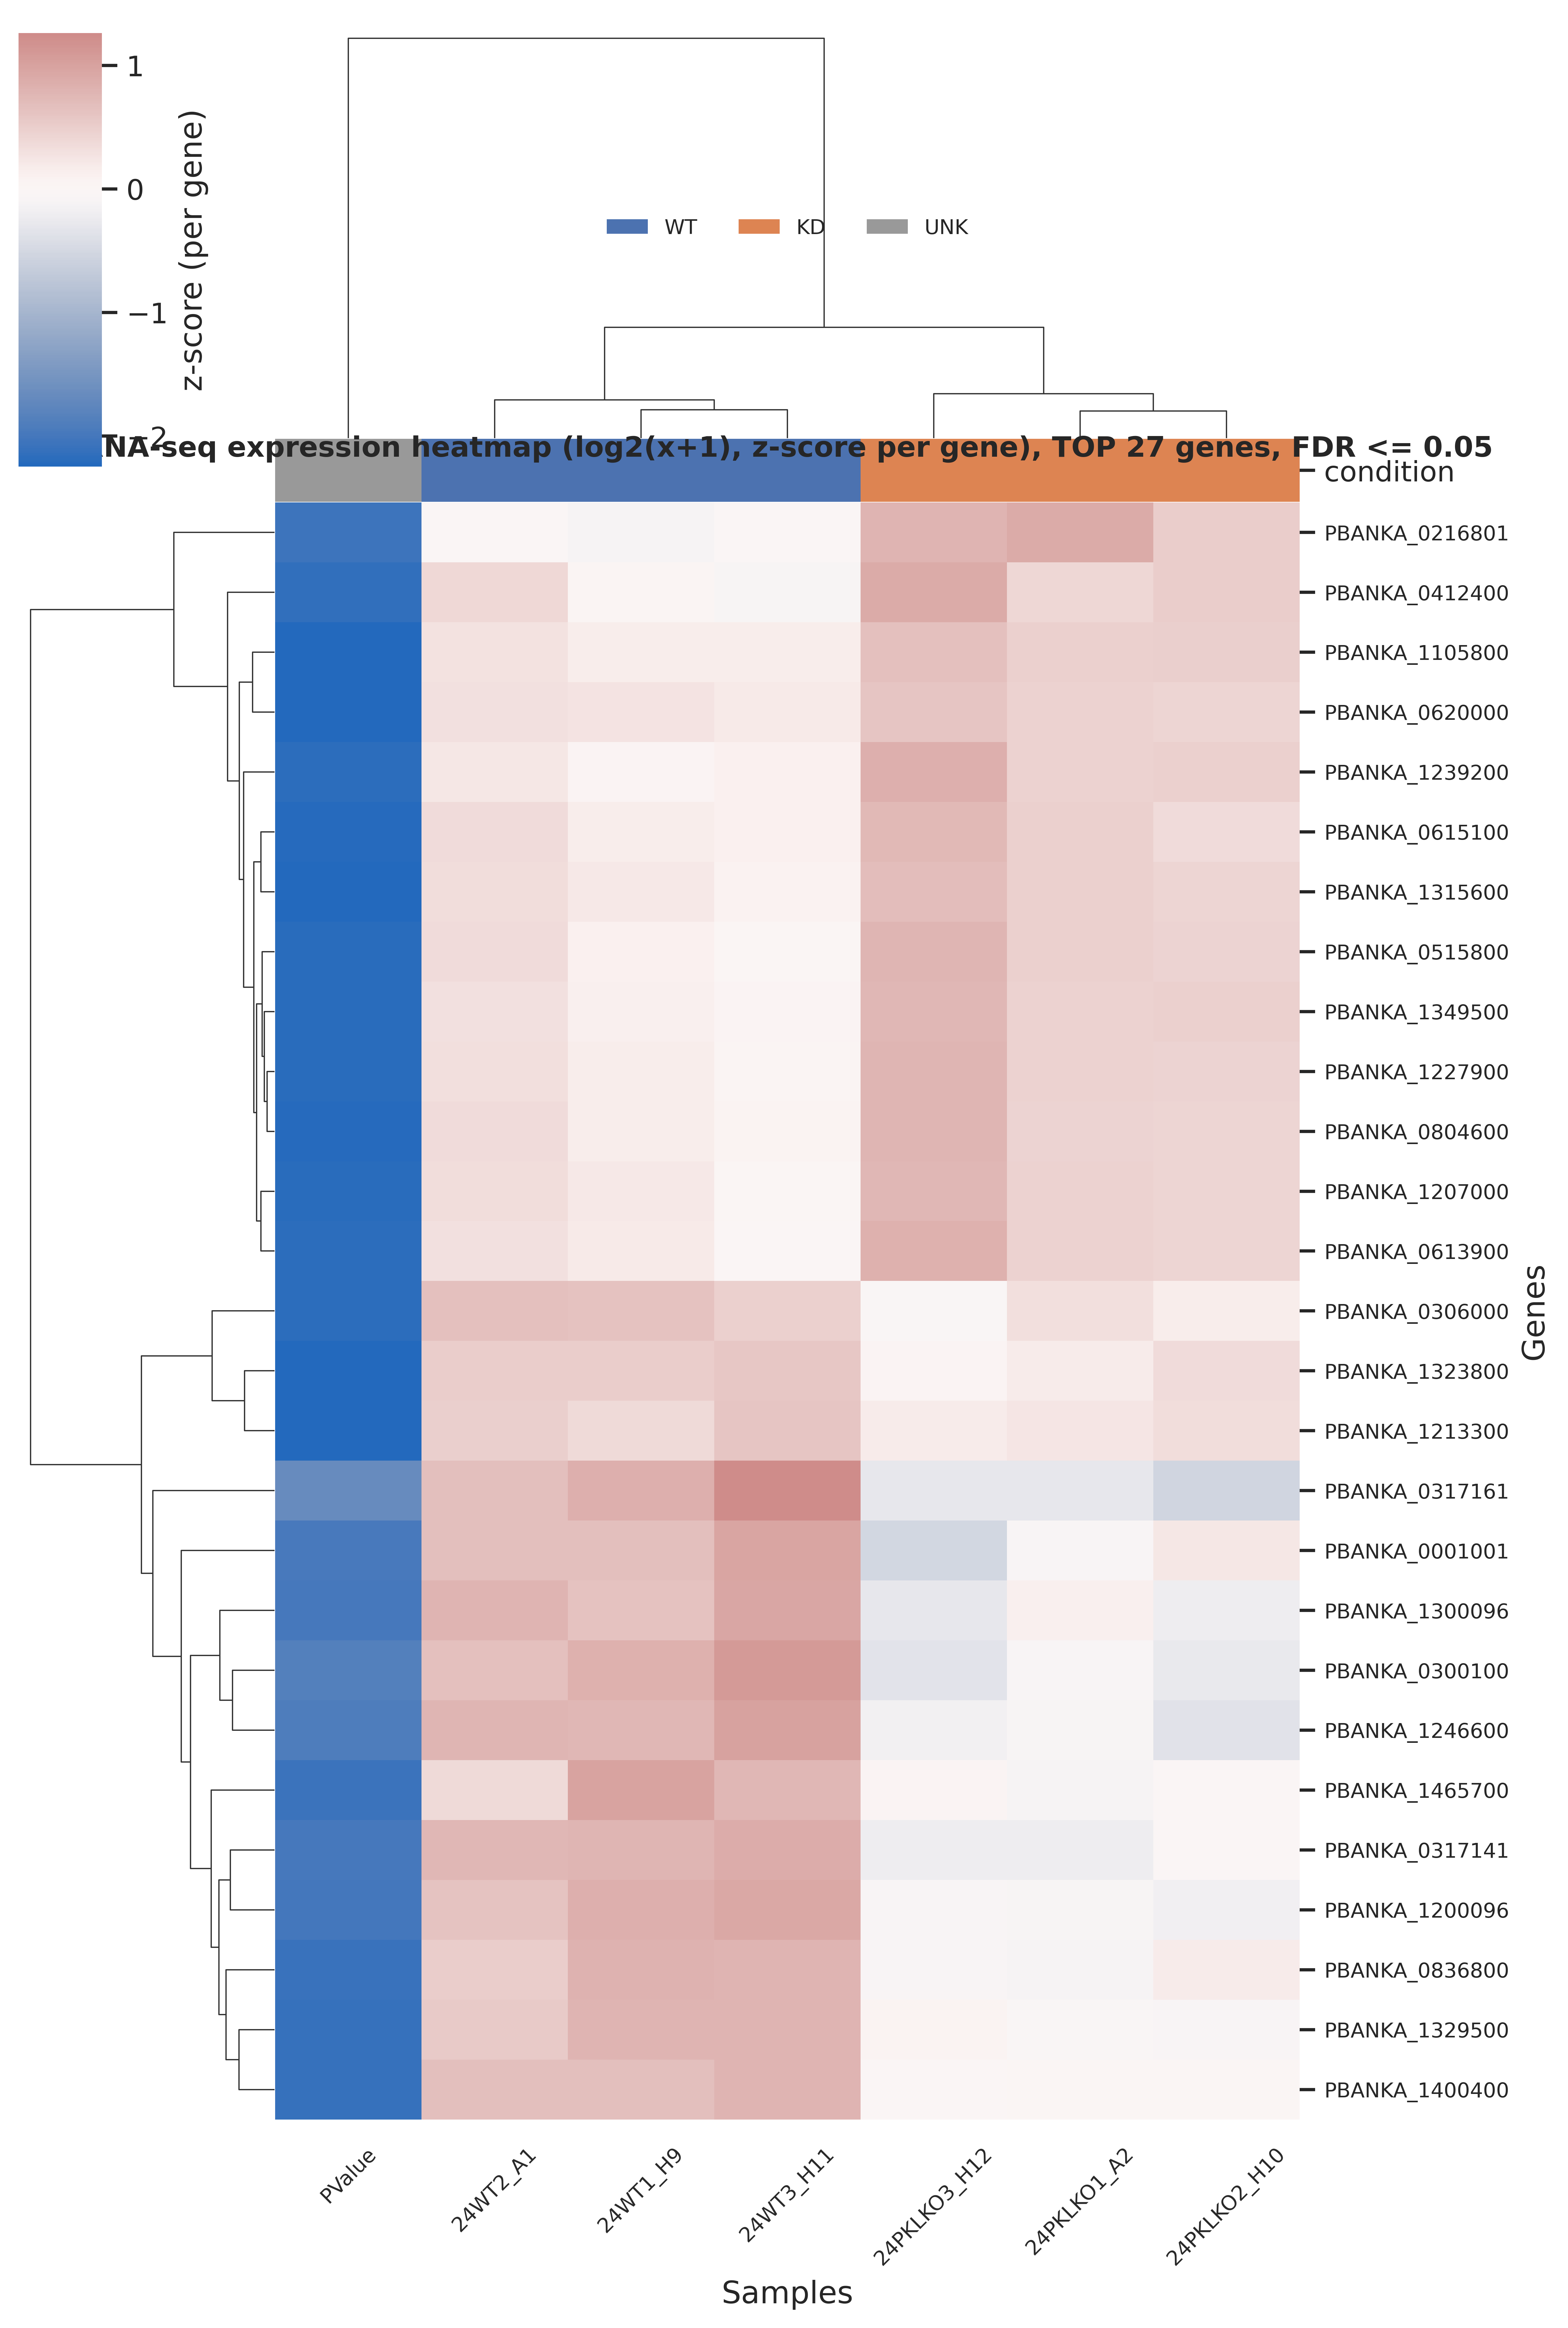

Heatmap generation complete.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 600

# Constants
SHORT_NAME = "pb"
TRIM_UNTRIM = "trimmed"

# Directory where this script lives (prefer file location; fallback to cwd)
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# ROOT = ../data relative to script directory
ROOT_DIR = (SCRIPT_DIR / ".." / "data").resolve()

# Input and output
COUNT_FILE  = ROOT_DIR / "output" / "edger_filtered_results.csv"
OUTPUT_FILE = ROOT_DIR / "output" / "edger_expression_heatmap.pdf"

# Plot controls
MIN_FDR = 0.05
TOP_N = 100
WIDTH, HEIGHT = 9, 13  # inches

# If your sample columns follow a prefix pattern, set it here, else leave as None
SAMPLE_PREFIX = None  # example: "24"

# If your CSV contains these columns, we will use them
PVAL_COL_CANDIDATES = ["PValue", "pvalue", "p_val", "pval"]
FDR_COL_CANDIDATES = ["FDR", "padj", "adj.P.Val"]
LFC_COL_CANDIDATES = ["log2FoldChange", "logFC"]

print("# Tool: RNA-seq Expression Heatmap (genes x samples)")
print(f"# Input: {COUNT_FILE}")
print(f"# Output: {OUTPUT_FILE}")

# Load results
df = pd.read_csv(COUNT_FILE)

# Identify gene name column (first column)
gene_col = df.columns[0]
df = df.set_index(gene_col)

# Find key columns
def first_present(cands, columns):
    for c in cands:
        if c in columns:
            return c
    return None

FDR_COL = first_present(FDR_COL_CANDIDATES, df.columns)
LFC_COL = first_present(LFC_COL_CANDIDATES, df.columns)

if FDR_COL is None:
    raise RuntimeError(f"Could not find an FDR column. Tried: {FDR_COL_CANDIDATES}")
if LFC_COL is None:
    raise RuntimeError(f"Could not find an LFC column. Tried: {LFC_COL_CANDIDATES}")

# Guess sample columns
non_sample_cols = set([FDR_COL, LFC_COL, "baseMean", "baseMeanA", "baseMeanB", "lfcSE", "stat",
                       "foldChange", "PAdj", "falsePos", "logCPM"])

candidate_cols = [c for c in df.columns if c not in non_sample_cols]

# Optional prefix filter if you want it
if SAMPLE_PREFIX is not None:
    sample_cols = [c for c in candidate_cols if str(c).startswith(SAMPLE_PREFIX)]
else:
    # Heuristic: sample columns are numeric-ish and not obvious stats columns
    sample_cols = candidate_cols

if len(sample_cols) < 2:
    raise RuntimeError("Could not identify sample columns. Set SAMPLE_PREFIX or adjust non_sample_cols.")

# Ensure expression columns are numeric
expr = df[sample_cols].apply(pd.to_numeric, errors="coerce")

# Filter genes by FDR threshold (use numeric FDR)
fdr_num = pd.to_numeric(df[FDR_COL], errors="coerce")
lfc_num = pd.to_numeric(df[LFC_COL], errors="coerce")

df_filtered = df.loc[fdr_num <= MIN_FDR].copy()
expr_filtered = expr.loc[df_filtered.index].copy()
lfc_filtered = lfc_num.loc[df_filtered.index].copy()
fdr_filtered = fdr_num.loc[df_filtered.index].copy()

# Drop genes that have too many NaNs in expression
expr_filtered = expr_filtered.dropna(axis=0, how="all")

if expr_filtered.empty:
    raise RuntimeError(f"No genes left after filtering (FDR <= {MIN_FDR}) and expression cleanup.")

# Top-N selection by abs(LFC), tie-break by FDR
rank_df = pd.DataFrame({
    "abs_lfc": np.abs(lfc_filtered.reindex(expr_filtered.index)),
    "fdr": fdr_filtered.reindex(expr_filtered.index),
})
rank_df = rank_df.dropna()

rank_df = rank_df.sort_values(["abs_lfc", "fdr"], ascending=[False, True])
top_genes = rank_df.index[:min(TOP_N, len(rank_df))]

expr_top = expr_filtered.loc[top_genes].copy()

# Expression transformation for heatmap
# For RNA-seq counts-like values, log2(x + 1) helps a lot.
expr_log = np.log2(expr_top + 1.0)

# Z-score per gene so rows are comparable (standard in expression heatmaps)
row_mean = expr_log.mean(axis=1)
row_std = expr_log.std(axis=1).replace(0, np.nan)
expr_z = expr_log.sub(row_mean, axis=0).div(row_std, axis=0)
expr_z = expr_z.fillna(0.0)

# Build sample annotation (WT vs KD) from column names
def infer_condition(sample_name: str) -> str:
    s = str(sample_name)
    if "WT" in s:
        return "WT"
    if "PKLKO" in s or "KO" in s or "KD" in s:
        # Your project seems to use PKLKO for treatment
        return "KD"
    return "UNK"

sample_conditions = pd.Series([infer_condition(c) for c in expr_z.columns], index=expr_z.columns, name="condition")

# Colors for column annotation
cond_palette = {
    "WT": "#4C72B0",
    "KD": "#DD8452",
    "KO": "#DD8452",
    "UNK": "#999999",
}
col_colors = sample_conditions.map(lambda x: cond_palette.get(x, "#999999"))

# Plot
sns.set_theme(style="white")

title = f"RNA-seq expression heatmap (log2(x+1), z-score per gene), TOP {len(expr_z)} genes, FDR <= {MIN_FDR}"

g = sns.clustermap(
    expr_z,
    row_cluster=True,
    col_cluster=True,
    cmap="vlag",
    center=0,
    figsize=(WIDTH, HEIGHT),
    col_colors=col_colors,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "z-score (per gene)"},
)

# Improve labels
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Genes")
g.ax_heatmap.set_title(title, pad=18, fontsize=11, fontweight="bold")

# Make x tick labels readable
g.ax_heatmap.tick_params(axis="x", labelrotation=45, labelsize=8)
# Y label size depends on gene count
nrows = expr_z.shape[0]
y_font = 8 if nrows <= 100 else 5
g.ax_heatmap.tick_params(axis="y", labelrotation=0, labelsize=y_font)

# Add a simple legend for conditions
for cond, color in [("WT", cond_palette["WT"]), ("KD", cond_palette["KD"]), ("UNK", cond_palette["UNK"])]:
    g.ax_col_dendrogram.bar(0, 0, color=color, label=cond, linewidth=0)
g.ax_col_dendrogram.legend(loc="center", ncol=3, frameon=False, fontsize=8)

print(f"Saving heatmap to: {OUTPUT_FILE}")
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FILE, bbox_inches="tight")
plt.show()
print("Heatmap generation complete.")
